In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df_info = df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [7]:
df = df.drop(columns=['Id'], errors="ignore")

In [8]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values>0].sort_values(ascending=False)

In [9]:
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [10]:
missing_values = df.isnull().mean()
missing_values = missing_values[missing_values>0].sort_values(ascending=False)
missing_values

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
GarageQual      0.055479
GarageCond      0.055479
BsmtExposure    0.026027
BsmtFinType2    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64

In [11]:
threshold = 0.65
columns_with_high_null_value = missing_values[missing_values>threshold].index.to_list()

In [12]:
columns_with_high_null_value

['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [13]:
df1 = df.drop(columns=columns_with_high_null_value,errors='ignore')

In [14]:
print(df1.shape)

(1460, 76)


In [15]:
import numpy as np

In [16]:
target_coorelation = df1.select_dtypes(include=[np.number]).corr()["SalePrice"].abs()

In [17]:
target_coorelation

MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [18]:
low_imapct_threshold = 0.1

low_impact_correlation = target_coorelation[target_coorelation<low_imapct_threshold].index.to_list()

In [19]:
df_2 = df1.drop(columns=low_impact_correlation,errors='ignore')

In [20]:
df_2

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [21]:
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
redundant_cols = [column for column in upper.columns if any(upper[column]>0.8)]
print(redundant_cols)

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [22]:
df3 = df_2.drop(columns=redundant_cols,errors='ignore')


In [23]:
df3.shape

(1460, 62)

## part-2

In [24]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   str    
 4   LotShape       1460 non-null   str    
 5   LandContour    1460 non-null   str    
 6   Utilities      1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   str    
 18  RoofMatl       1460

### Simple Imputation

Instead of deleting, we fill the missing values with estimates.

(a) Mean Imputation (Numerical Data)

(b) Median Imputation (Numerical Data)

(c) Mode Imputation (Categorical Data)


In [25]:
df_mean = df3.copy()
df_mean.fillna({"LotFrontage" :df_mean["LotFrontage"].mean()}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [26]:
df_median = df3.copy()

In [27]:
df_median.fillna({"LotFrontage":df_median["LotFrontage"].median()}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [28]:
df_mode = df3.copy()

In [29]:
df_mode["GarageType"].mode()[0]

'Attchd'

In [30]:
df_mode.fillna({"GarageType":df_mode["GarageType"].mode()[0]}, inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [31]:
df_mode['GarageType'].value_counts()

GarageType
Attchd     951
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

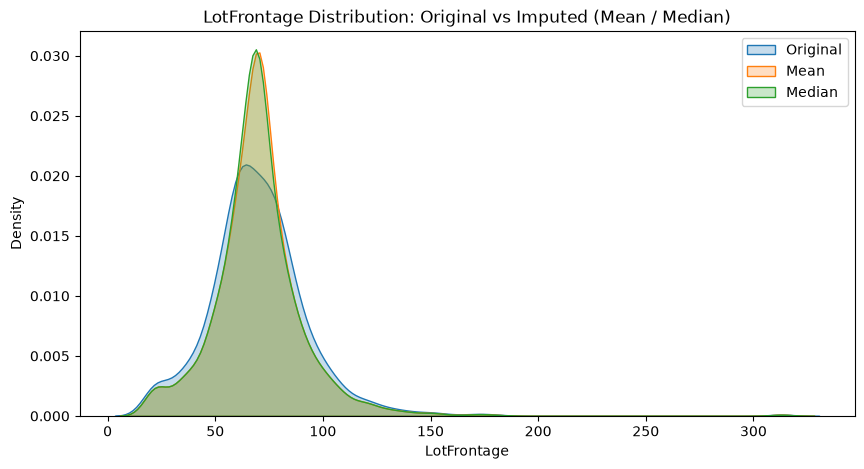

In [32]:
plt.figure(figsize=(10,5))
sns.kdeplot(df["LotFrontage"], label = "Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label = "Mean", fill=True)
sns.kdeplot(df_median["LotFrontage"], label = "Median", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median)")
plt.show()

In [33]:
from sklearn.impute import KNNImputer


In [34]:
knn_imputer = KNNImputer(n_neighbors=5)

In [35]:
df_knn = df3.copy()

In [36]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns


In [37]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])

In [38]:
def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison

In [39]:
compare_imputation(df3, df_knn, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
31,NaN,68.4
42,NaN,69.6
43,NaN,70.6
50,NaN,77.8
64,NaN,76.4


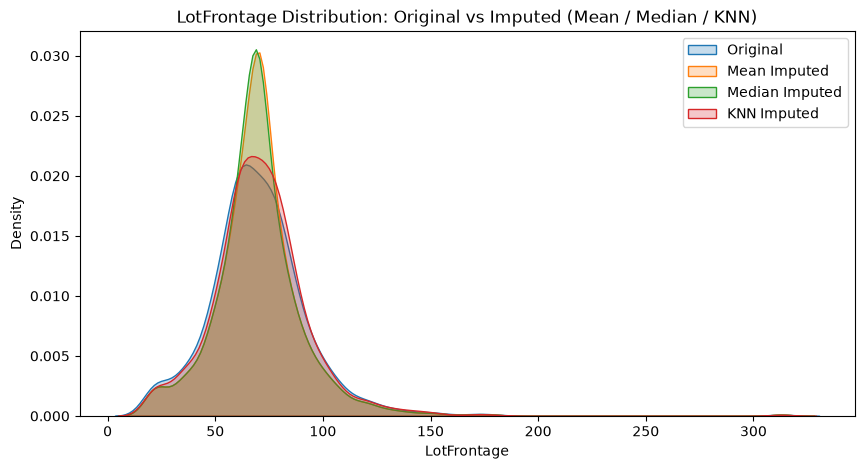

In [40]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

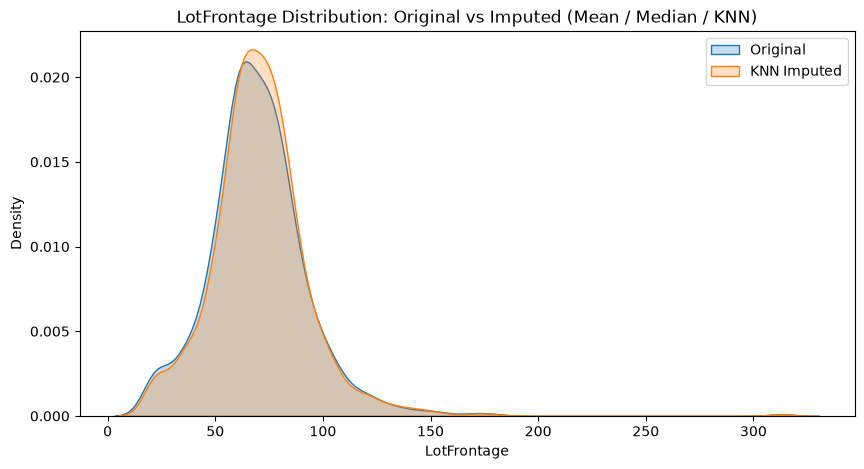

In [41]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
# sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

# Part-3

### Linear Regression

In [42]:
df_reg = df3.copy()

In [43]:
from sklearn.linear_model import LinearRegression

In [46]:
train_df=df_reg.dropna(subset="LotFrontage")
test_df = df_reg[df["LotFrontage"].isnull()]

In [48]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   str    
 4   LotShape       1201 non-null   str    
 5   LandContour    1201 non-null   str    
 6   Utilities      1201 non-null   str    
 7   LotConfig      1201 non-null   str    
 8   LandSlope      1201 non-null   str    
 9   Neighborhood   1201 non-null   str    
 10  Condition1     1201 non-null   str    
 11  Condition2     1201 non-null   str    
 12  BldgType       1201 non-null   str    
 13  HouseStyle     1201 non-null   str    
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   str    
 18  RoofMatl       1201 non-

In [50]:
target_corr_ml = df1.select_dtypes(include=[np.number]).corr()["LotFrontage"].abs()
target_corr_ml

MSSubClass       0.386347
LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
OverallCond      0.059213
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtFinSF2       0.049900
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
1stFlrSF         0.457181
2ndFlrSF         0.080177
LowQualFinSF     0.038469
GrLivArea        0.402797
BsmtFullBath     0.100949
BsmtHalfBath     0.007234
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
TotRmsAbvGrd     0.352096
Fireplaces       0.266639
GarageYrBlt      0.070250
GarageCars       0.285691
GarageArea       0.344997
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
3SsnPorch        0.070029
ScreenPorch      0.041383
PoolArea         0.206167
MiscVal          0.003368
MoSold           0.011200
YrSold           0.007450
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [53]:
X_train = train_df[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]]
y_train = train_df["LotFrontage"]


In [54]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-1.5 , 0.01, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['LotArea','OverallQual','TotalBsmtSF','GrLivArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,39.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [55]:
reg.coef_

array([ 8.90135199e-04, -1.49550808e+00,  1.24430130e-02,  1.16904327e-02])

In [57]:
test_df = test_df[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]].info()

<class 'pandas.DataFrame'>
Index: 259 entries, 7 to 1446
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LotArea      259 non-null    int64
 1   OverallQual  259 non-null    int64
 2   TotalBsmtSF  259 non-null    int64
 3   GrLivArea    259 non-null    int64
dtypes: int64(4)
memory usage: 10.1 KB


In [ ]:
df_reg.loc[df_reg["LotFrontage"].isnull(), "LotFrontage"] = reg.predict(test_df[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]])